In [120]:
import pandas as pd
import os
from matplotlib import pyplot as plt, cm
from matplotlib.colors import LightSource

In [106]:
dfs = []
directory_path = "../metrics"
for file in os.listdir(directory_path):
    if file.endswith(".csv"):
        file_path = os.path.join(directory_path, file)
        dfs.append(pd.read_csv(file_path, delimiter=';', quotechar='"'))

print(len(dfs))
df = pd.concat(dfs, ignore_index=True)
df = df[df.metric == 'rmse']
# df = df[df.autoregression_steps < 97]

99


In [107]:
df

,autoregression_steps,metric,mean/std,variable,level,lat_weighted,value
4,63,rmse,mean,all,-1,False,1.780429e+09
5,63,rmse,std,all,-1,False,5.354798e+06
10,63,rmse,mean,all,-1,True,1.396664e+09
11,63,rmse,std,all,-1,True,3.111553e+06
16,63,rmse,mean,ocean_heat_content_for_the_total_water_column,-1,False,1.246555e+10
...,...,...,...,...,...,...,...
42755,24,rmse,std,geopotential,3,True,4.898721e-05
42760,24,rmse,mean,geopotential,4,False,1.256002e-03
42761,24,rmse,std,geopotential,4,False,7.204120e-05
42766,24,rmse,mean,geopotential,4,True,8.380567e-04


In [108]:
over_all_vars = df[df.variable == "all"]

means = over_all_vars[over_all_vars["mean/std"] == "mean"]
lat_means = means[means.lat_weighted == True]
means = means[means.lat_weighted == False]
lat_means = lat_means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
means = means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_means = lat_means.rename(columns={'value': 'mean'})
means = means.rename(columns={'value': 'mean'})

stds = over_all_vars[over_all_vars["mean/std"] == "std"]
lat_stds = stds[stds.lat_weighted == True]
stds = stds[stds.lat_weighted == False]
lat_stds = lat_stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
stds = stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_stds = lat_stds.rename(columns={'value': 'std'})
stds = stds.rename(columns={'value': 'std'})

mean_over_vars = pd.merge(means, stds, on=['autoregression_steps', 'metric'])
mean_over_vars_lat = pd.merge(lat_means, lat_stds, on=['autoregression_steps', 'metric'])

In [109]:
metric_colors = {'mae': 'blue', 'mse': 'green', 'rmse': 'red'}


def plot_mean_std(df):
    plt.figure(figsize=(10, 6))

    for metric in df['metric'].unique():
        metric_data = df[df['metric'] == metric]
        metric_data = metric_data.sort_values(by=['autoregression_steps'])
        print(metric_data)
        plt.plot(
            metric_data['autoregression_steps'],
            metric_data['mean'],
            label=metric,
            color=metric_colors[metric]
        )
        plt.fill_between(
            metric_data['autoregression_steps'],
            metric_data['mean'] - metric_data['std'],
            metric_data['mean'] + metric_data['std'],
            color=metric_colors[metric],
            alpha=0.1
        )

    plt.title('Fehlerkennzahlen über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Fehler (Mittelwert ± Standardabweichung)')
    # plt.yscale('log')
    plt.legend(title='Metrik')
    plt.grid(True)
    plt.show()


color_dict = {
    0: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
    1: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
    2: (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
    3: (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
    4: (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
    5: (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
    6: (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
    7: (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
    8: (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
    9: (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
    10: (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
    11: (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
    12: (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
    13: (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
    14: (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
    15: (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
    16: (0.7725490196078432, 0.6901960784313725, 0.8352941176470589, 1.0),
    17: (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
    18: (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
    19: (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
    20: (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
    21: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
    22: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
    23: (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
    24: (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0),
    25: (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0),
    26: (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
    27: (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
    28: (0.7372549019607844, 0.7411764705882353, 0.13333333333333333, 1.0),
    29: (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
    30: (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
    31: (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0),
    32: (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0),
    33: (0.6196078431372549, 0.8549019607843137, 0.8980392156862745, 1.0),
    34: (0.6196078431372549, 0.8549019607843137, 0.8980392156862745, 1.0)
}


def plot_variable_data(df):
    """
    Plots data for each variable with separate lines and error bands.

    Parameters:
    df (DataFrame): The DataFrame containing the data. It should have columns:
        'variable', 'autoregression_steps', 'mean', and 'std'.
    variable_colors (dict): A dictionary mapping each variable to a color.
    """
    plt.figure(figsize=(10, 6))

    for idx, variable in enumerate(df['variable'].unique()):
        variable_data = df[df['variable'] == variable]
        plt.plot(
            variable_data['autoregression_steps'],
            variable_data['mean'],
            label=variable,
            color=color_dict.get(idx, 'black')  # Default to 'black' if no color specified
        )
        plt.fill_between(
            variable_data['autoregression_steps'],
            variable_data['mean'] - variable_data['std'],
            variable_data['mean'] + variable_data['std'],
            color=color_dict.get(idx, 'black'),
            alpha=0.2
        )

    plt.title('Daten pro Variable über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Datenwert (Mittelwert ± Standardabweichung)')
    plt.legend(title='Variable')
    plt.grid(True)
    plt.show()

    autoregression_steps metric          mean           std
16                     2   rmse  1.784518e+09  5.203169e+06
41                     3   rmse  1.780188e+09  5.648354e+06
7                      4   rmse  1.779956e+09  5.534051e+06
33                     5   rmse  1.779605e+09  5.301865e+06
56                     6   rmse  1.779635e+09  5.315494e+06
..                   ...    ...           ...           ...
66                   101   rmse  1.780184e+09  3.222271e+06
46                   102   rmse  1.779992e+09  3.580270e+06
18                   103   rmse  1.780336e+09  4.074299e+06
30                   104   rmse  1.778621e+09  4.015170e+06
1                    105   rmse  1.774604e+09  0.000000e+00

[99 rows x 4 columns]


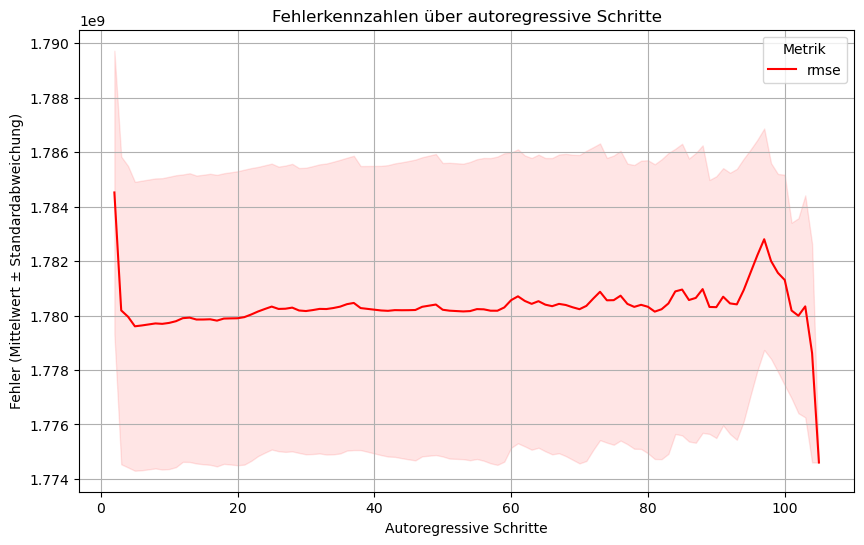

In [110]:
plot_mean_std(mean_over_vars)

    autoregression_steps metric          mean           std
16                     2   rmse  1.398368e+09  3.129693e+06
41                     3   rmse  1.396132e+09  3.014629e+06
7                      4   rmse  1.396061e+09  2.965049e+06
33                     5   rmse  1.395977e+09  2.966297e+06
56                     6   rmse  1.396003e+09  2.976527e+06
..                   ...    ...           ...           ...
66                   101   rmse  1.397522e+09  2.116940e+06
46                   102   rmse  1.397160e+09  2.227505e+06
18                   103   rmse  1.396921e+09  2.523557e+06
30                   104   rmse  1.395439e+09  1.735076e+06
1                    105   rmse  1.393705e+09  0.000000e+00

[99 rows x 4 columns]


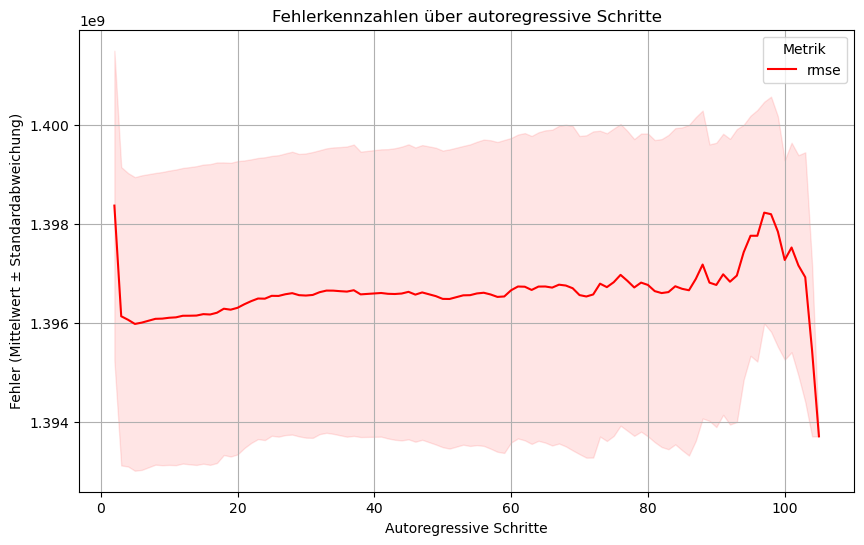

In [111]:
plot_mean_std(mean_over_vars_lat)

In [112]:
over_vars = df[df.variable != "all"]
over_vars = over_vars.pivot_table(
    index=["autoregression_steps", "metric", "variable", "level", "lat_weighted"],
    columns="mean/std",
    values="value"
).reset_index()

level_vars = over_vars[over_vars.level >= 0]
level_vars = level_vars[level_vars.metric == 'mae']
surface_vars = over_vars[over_vars.level == -1]

In [113]:
for level in set(level_vars.level):
    plot_df = level_vars[level_vars.level == level]
    # print(plot_df)
    plot_variable_data(plot_df)

In [114]:
import torch
import numpy as np

a = torch.tensor(np.array([1, 2, np.NaN]))
mask = ~torch.isnan(a)
a * mask

tensor([1., 2., nan], dtype=torch.float64)

In [115]:
outs = [torch.tensor(np.random.rand(16, 35, 121, 240)) for i in range(1)]
stacked_outs = torch.stack(outs, dim=1)
stacked_outs.shape

torch.Size([16, 1, 35, 121, 240])

In [116]:
model_input = torch.rand((16, 35, 121, 240))
a = torch.rand((16, 2, 35, 121, 240))
a[:, 1, :, :, :].shape

torch.Size([16, 35, 121, 240])

In [117]:
over_all_vars = df[df.variable != "all"].copy()
over_all_vars['variable_combined'] = over_all_vars.apply(
    lambda row: f"{row['variable']}_{row['level']}" if row['level'] >= 0 else row['variable'],
    axis=1
)

means = over_all_vars[over_all_vars["mean/std"] == "mean"]
lat_means = means[means.lat_weighted == True]
lat_means = lat_means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_means = lat_means.rename(columns={'value': 'mean', 'variable_combined': 'var'})

stds = over_all_vars[over_all_vars["mean/std"] == "std"]
lat_stds = stds[stds.lat_weighted == True]
lat_stds = lat_stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_stds = lat_stds.rename(columns={'value': 'std', 'variable_combined': 'var'})

mean_over_vars_lat = pd.merge(lat_means, lat_stds, on=['var', 'autoregression_steps', 'metric'])

In [118]:
a = mean_over_vars_lat[mean_over_vars_lat['var'] == '10m_u_component_of_wind']
b = a[a['autoregression_steps'] == 2]

In [119]:
ds = mean_over_vars_lat.sort_values(by=['autoregression_steps', 'var'])
vars = ds['var'].unique()
ar_steps = ds['autoregression_steps'].unique()

mean_vals = np.zeros((vars.size, ar_steps.size))
std_vals = np.zeros((vars.size, ar_steps.size))
for x, var in enumerate(vars):
    for y, ar in enumerate(ar_steps):
        vf = ds[ds['var'] == var]
        af = vf[vf['autoregression_steps'] == ar]
        mean_vals[x,y] = float(af['mean'].iloc[0])
        std_vals[x,y] = float(af['std'].iloc[0])

[  2   3   4   5   6   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  41  42  43  44  45  46  47  49  50  51  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105]


(35, 99)

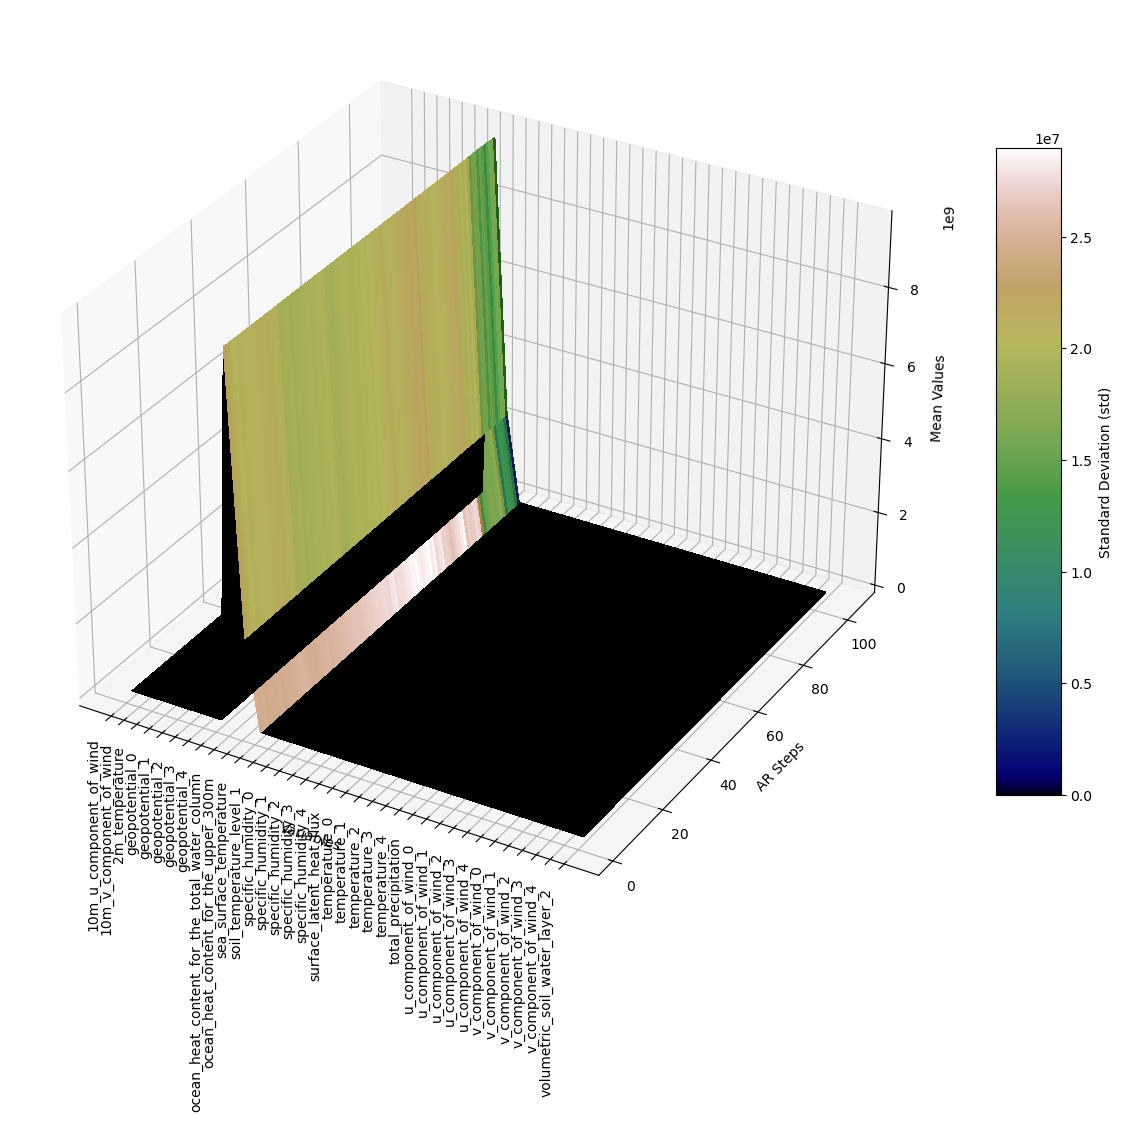

In [133]:
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), figsize=(16, 12))

var_indices = np.arange(len(vars))
X, Y = np.meshgrid(var_indices, ar_steps, indexing='ij')

cmap = cm.gist_earth
ls = LightSource(270, 45)
rgb = ls.shade(std_vals, cmap=cmap, vert_exag=0.1, blend_mode='soft')
surf = ax.plot_surface(X, Y, mean_vals, rstride=1, cstride=1, facecolors=rgb,
                       linewidth=0, antialiased=False, shade=False)

ax.set_xlabel('Variables')
ax.set_ylabel('AR Steps')
ax.set_zlabel('Mean Values')

ax.set_xticks(var_indices)
ax.set_xticklabels(vars, rotation=90, ha='right')

mappable = cm.ScalarMappable(cmap=cmap)  # Erstellt ein ScalarMappable-Objekt für die Colorbar
mappable.set_array(std_vals)             # Verknüpft die Daten (std_vals) mit dem Farbschema
cbar = fig.colorbar(mappable, ax=ax, shrink=0.7, aspect=10)  # Colorbar hinzufügen
cbar.set_label('Standard Deviation (std)')   

plt.show()